# Figure 5 — Melody-G generalization with scRNA-seq embeddings

This notebook reproduces Figure 5 panels from the exported source CSV files.

**Background.** Melody-G extends the sequence-based Melody framework by conditioning methylation prediction on cell-state embeddings derived from single-cell RNA-seq foundation models. To evaluate whether these embeddings support generalization beyond profiled tissues, five cell types are held out as unseen test sets: **Aorta-Endothel, Blood-Granulocytes, Blood-Monocytes, Cortex-Neuron, and Pancreas-Delta**. Melody-G is compared with an MT-mean baseline, which averages methylation profiles from the 34 seen cell types.

**Figure 5 focus.** Figure 5 evaluates Melody-G from three complementary angles: unseen-cell performance, gene-level interpretation through in silico knockouts, and ablations of the scRNA-seq embedding strategy.

**Panels and source CSVs**

| Panel | CSV | Content |
| --- | --- | --- |
| Figure 5A | `figure_5A.csv` | Melody-G1, Melody-G2, and MT-mean AUCs across five unseen cell types |
| Figure 5B | `figure_5B.csv` | Seen-cell performance comparison across methods and validation splits |
| Figure 5D | `figure_5D.csv` | KEGG pathway annotation of high-impact genes from in silico knockouts |
| Figure 5E | `figure_5E.csv` | Directional influence scores from 1,200 in silico gene knockouts, visualized after central 98% trimming |
| Figure 5F | `figure_5F.csv` | Ablation of scRNA-seq embedding fusion strategies |
| Figure 5G | `figure_5G.csv` | Effect of scRNA-seq sample size on model performance |
| Figure 5H | `figure_5H.csv` | Comparison of embeddings from different scRNA-seq foundation models |

The current notebook implements **Figure 5A, 5B, 5D, 5E, 5F, 5G, and 5H**. Figures are rendered inline.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm, font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
def find_submit_dir():
    """Locate the submit directory whether the notebook runs from repo root or submit/."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "submit", *[parent / "submit" for parent in cwd.parents]]
    for candidate in candidates:
        if (candidate / "Data" / "Figure5" / "figure_5A.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate Data/Figure5/figure_5A.csv")


SUBMIT_DIR = find_submit_dir()
DATA_DIR = SUBMIT_DIR / "Data" / "Figure5"
CSV_DIR = DATA_DIR

In [3]:
def use_nature_style():
    font_candidates = [
        SUBMIT_DIR.parent / "draw_figs" / "ARIAL.TTF",
        SUBMIT_DIR / "ARIAL.TTF",
    ]
    for font_path in font_candidates:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            mpl.rcParams["font.family"] = "Arial"
            break
    else:
        mpl.rcParams["font.family"] = "DejaVu Sans"

    mpl.rcParams.update({
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,
        "figure.dpi": 300,
    })


def calculate_robust_ylim(vals, padding_ratio=0.06, q=(2, 98), hard_bounds=None):
    values = np.asarray(vals, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (0, 1)

    qlo, qhi = np.percentile(values, q[0]), np.percentile(values, q[1])
    vmin, vmax = values.min(), values.max()
    span = qhi - qlo
    pad = padding_ratio * span if span > 0 else 0.02
    y0, y1 = min(qlo - pad, vmin), max(qhi + pad, vmax)

    if hard_bounds is not None:
        y0 = max(hard_bounds[0], y0)
        y1 = min(hard_bounds[1], y1)
    return (y0, y1)
def load_auc_panel(panel_label, csv_name, row_order=None):
    df = pd.read_csv(CSV_DIR / csv_name, index_col=0)
    if row_order is not None:
        df = df.loc[row_order]

    return df




# Figure 5A — Melody-G performance on unseen cell types

Figure 5A compares Melody-G's two training stages with the MT-mean baseline on the five held-out cell types.

- **Melody-G1** uses scRNA-seq embeddings to guide methylation prediction in unseen biological contexts.
- **Melody-G2** is further fine-tuned on cell-type-specific regions, emphasizing localized regulatory signatures.
- **MT-mean** is the baseline obtained by averaging the methylation profile of the 34 seen cell types.

Each scatter point is the CpG prediction AUC for one unseen cell type. Bars show the mean AUC across the five unseen cell types, with error bars indicating the standard deviation.

In [4]:
df_5A = pd.read_csv(CSV_DIR / "figure_5A.csv", index_col=0)

method_order = ["Melody-G1", "Melody-G2", "MT-mean"]
cell_type_order = [
    "Pancreas-Delta",
    "Blood-Granulocytes",
    "Blood-Monocytes",
    "Aorta-Endothel",
    "Cortex-Neuron",
]

df_5A = df_5A.loc[method_order, cell_type_order]

figure_5a = df_5A

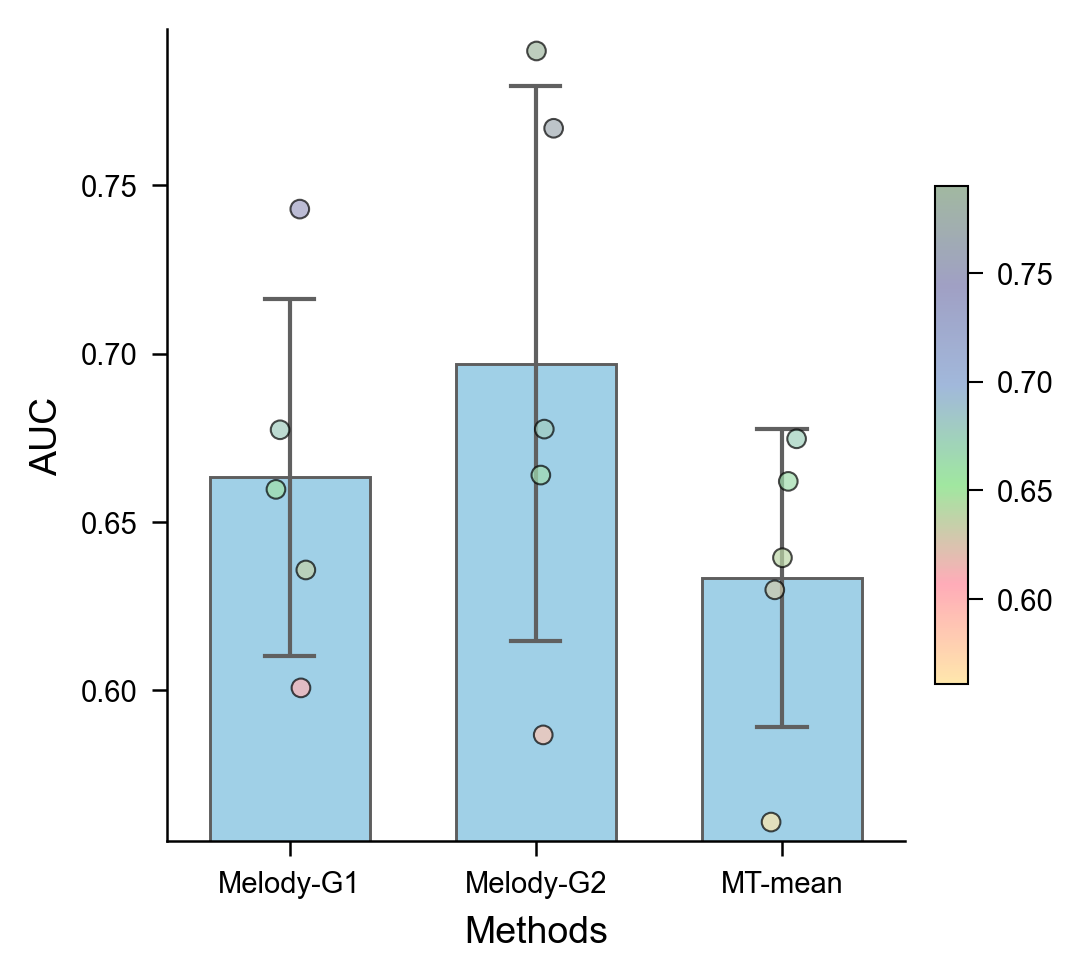

In [5]:
def plot_auc_panel(data, xlabel="Methods"):
    use_nature_style()

    labels = data.index.tolist()
    values_by_method = [row.to_numpy(dtype=float) for _, row in data.iterrows()]
    all_values = np.concatenate(values_by_method)
    positions = np.arange(len(values_by_method))
    scatter_cmap = LinearSegmentedColormap.from_list(
        "figure5a_pastel",
        ["#FFE7AC", "#FFACB8", "#A0E7A0", "#A1B8DB", "#A0A0C4", "#A1B8A1"],
        N=256,
    )
    norm = Normalize(vmin=np.min(all_values), vmax=np.max(all_values))

    fig, ax = plt.subplots(figsize=(89 / 25.4, 80 / 25.4), layout="constrained")

    ax.bar(
        positions,
        [np.mean(values) for values in values_by_method],
        width=0.65,
        facecolor="#A0D0E7",
        edgecolor="#5E5E5E",
        linewidth=0.7,
        zorder=1,
    )

    for position, values in zip(positions, values_by_method):
        mean_value = np.mean(values)
        sd = np.std(values, ddof=1)
        lo, hi = mean_value - sd, mean_value + sd
        ax.vlines(position, lo, hi, colors="#606060", linewidth=1.0, zorder=2)
        for y in (lo, hi):
            ax.plot([position - 0.1, position + 0.1], [y, y], color="#606060", linewidth=1.0)

    rng = np.random.default_rng(2024)
    for position, values in zip(positions, values_by_method):
        ax.scatter(
            position + rng.normal(0, 0.04, size=len(values)),
            values,
            s=20,
            alpha=0.7,
            c=scatter_cmap(norm(values)),
            edgecolors="black",
            linewidths=0.5,
            rasterized=True,
            zorder=3,
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

    ylim = calculate_robust_ylim(all_values, hard_bounds=(0, 1))

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_xlim(positions[0] - 0.5, positions[-1] + 0.5)
    ax.set_ylim(*ylim)

    scalar_mappable = cm.ScalarMappable(norm=norm, cmap=scatter_cmap)
    colorbar = fig.colorbar(scalar_mappable, ax=ax, fraction=0.045, pad=0.04, aspect=15)
    colorbar.outline.set_linewidth(0.5)
    colorbar.ax.tick_params(width=0.5)

    return fig, ax


fig, ax = plot_auc_panel(figure_5a)
plt.show()

# Figure 5B — Melody-G performance on seen cell types

Figure 5B evaluates Melody-G on the cell types used during training and compares it with sequence-only or cell-type-specific baselines. The manuscript describes this as a trade-off: Melody-G can generalize to unseen cell types by learning a harder cell-conditioned task, but this broad generalization can slightly reduce performance on seen cell types relative to specialized ST/MT models.

The source CSV is in long format with columns `model`, `track`, `split`, `metric`, and `value`. For each validation split, the plot shows the AUC distribution across shared seen cell-type tracks for five models.

In [6]:
figure_5b = pd.read_csv(CSV_DIR / "figure_5B.csv")
figure_5b = figure_5b[figure_5b["metric"] == "AUC"].copy()

model_order_5b = ["Melody-G1", "Melody-G2", "INTERACT", "ST", "MT"]
split_order_5b = ["VALID", "TEST", "SAMPLE_VALID", "SAMPLE_TEST"]

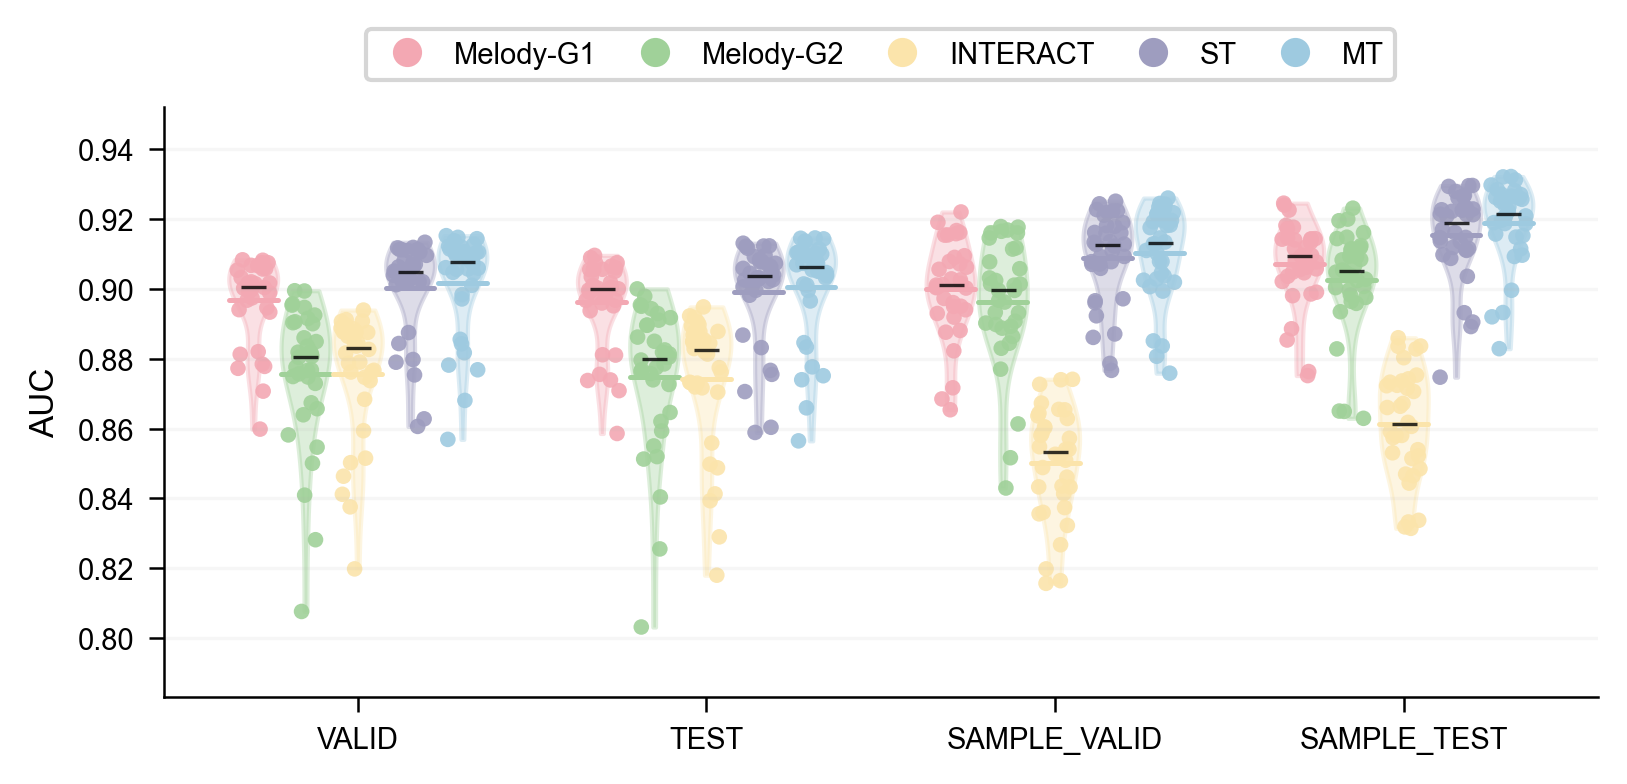

In [7]:
def collect_figure_5b_values(df, split, model_order):
    split_df = df[df["split"] == split]
    track_sets = {
        model: set(split_df.loc[split_df["model"] == model, "track"])
        for model in model_order
    }
    common_tracks = sorted(set.intersection(*track_sets.values()))
    return {
        model: split_df[
            (split_df["model"] == model) & (split_df["track"].isin(common_tracks))
        ].sort_values("track")["value"].to_numpy(dtype=float)
        for model in model_order
    }


def plot_figure_5b(df):
    use_nature_style()

    model_colors = {
        "Melody-G1": "#f3a8b3",
        "Melody-G2": "#a0d199",
        "INTERACT": "#fbe4ab",
        "ST": "#9e9dbf",
        "MT": "#9ecae0",
    }
    rng = np.random.default_rng(42)
    per_split_values = [
        collect_figure_5b_values(df, split, model_order_5b)
        for split in split_order_5b
    ]
    all_values = np.concatenate([
        values for split_values in per_split_values for values in split_values.values()
    ])
    y_min, y_max = np.nanmin(all_values), np.nanmax(all_values)
    ylims = (max(0, y_min - 0.02), min(1, y_max + 0.02))

    fig, ax = plt.subplots(figsize=(3.54 * 1.5, 5.0 * 0.5), constrained_layout=True)
    x_base = np.arange(len(split_order_5b))

    for i, split_values in enumerate(per_split_values):
        offsets = (np.arange(len(model_order_5b)) - (len(model_order_5b) - 1) / 2) * 0.15
        for offset, model in zip(offsets, model_order_5b):
            values = split_values[model]
            position = x_base[i] + offset
            color = model_colors[model]

            violin = ax.violinplot(
                [values],
                positions=[position],
                widths=0.70 / len(model_order_5b),
                showmeans=False,
                showextrema=False,
                showmedians=False,
            )
            for body in violin["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.35)

            ax.scatter(
                position + rng.uniform(-0.05, 0.05, size=values.size),
                values,
                s=14,
                alpha=0.9,
                marker="o",
                facecolors=color,
                edgecolors="none",
            )
            ax.plot(
                [position - 0.07, position + 0.07],
                [np.nanmean(values), np.nanmean(values)],
                lw=1.2,
                color=color,
                solid_capstyle="round",
            )
            ax.plot([position], [np.nanmedian(values)], marker="_", color="k", ms=6, mew=0.8, alpha=0.8)

    ax.set_xticks(x_base)
    ax.set_xticklabels(split_order_5b, rotation=0)
    ax.set_ylabel("AUC")
    ax.grid(axis="y", linestyle="-", alpha=0.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(*ylims)

    handles = [
        Line2D([0], [0], marker="o", linestyle="", color=model_colors[model], label=model, markersize=6)
        for model in model_order_5b
    ]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=len(model_order_5b), handletextpad=0.6, columnspacing=1.0)
    return fig, ax


fig, ax = plot_figure_5b(figure_5b)
plt.show()

# Figure 5D — Gene-level impact from in silico knockouts

Figure 5D summarizes gene-level drivers identified by in silico gene knockout using Pancreas-Delta scRNA-seq embeddings. In the manuscript, genes are ranked by the magnitude of their directional influence score, and high-impact genes such as **MMP3** and **HLA-DRB5** are linked to enriched biological pathways.

The source CSV here contains the final genes, scaled impact scores, and KEGG pathway annotations used for plotting. The original analysis script derives these genes from knockout scores and KEGG enrichment results; this notebook starts from the exported plotting table and draws the ranked gene-score barplot directly.

In [8]:
FIGURE_5D_REQUIRED_COLUMNS = {
    "gene",
    "scores",
    "KEGG Pathway",
}
FIGURE_5D_PATHWAY_METADATA = {
    "Complement and coagulation cascades": (1, 1.898578e-26),
    "ECM-receptor interaction": (2, 1.477544e-18),
    "Malaria": (3, 3.839139e-14),
    "Rheumatoid arthritis": (4, 1.477544e-18),
}
FIGURE_5D_CSV = CSV_DIR / "figure_5D.csv"


def _parse_figure5d_bool(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    normalized = str(value).strip().lower()
    if normalized in {"true", "1"}:
        return True
    if normalized in {"false", "0"}:
        return False
    raise ValueError(f"Invalid Figure 5D significance flag: {value!r}")


def load_figure_5d(figure_csv):
    figure_csv = Path(figure_csv).expanduser()
    if not figure_csv.is_file():
        raise FileNotFoundError(
            "Figure 5D requires its three-column plotting CSV; "
            f"file not found: {figure_csv}"
        )

    frame = pd.read_csv(figure_csv)
    missing = sorted(FIGURE_5D_REQUIRED_COLUMNS - set(frame.columns))
    if missing:
        raise ValueError(f"Figure 5D selected-gene CSV is missing columns: {missing}")
    if len(frame) != 20:
        raise ValueError(f"Figure 5D requires exactly 20 genes, found {len(frame)}")
    if frame["gene"].isna().any() or frame["gene"].duplicated().any():
        raise ValueError("Figure 5D genes must be unique and non-null")
    if frame["KEGG Pathway"].isna().any():
        raise ValueError("Figure 5D pathway assignments must be non-null")

    frame = frame.copy()
    frame["scores"] = pd.to_numeric(frame["scores"], errors="raise")
    if not np.isfinite(frame["scores"].to_numpy(dtype=float)).all():
        raise ValueError("Figure 5D scores must be finite")
    if np.any(np.abs(frame["scores"].to_numpy(dtype=float)) > 1.0 + 1e-12):
        raise ValueError("Piecewise-scaled Figure 5D scores must lie in [-1, 1]")

    frame["piecewise_scaled_score"] = frame["scores"]
    frame["absolute_piecewise_scaled_score"] = frame["scores"].abs()
    frame["assigned_pathway"] = frame["KEGG Pathway"]
    frame = frame.sort_values(
        "absolute_piecewise_scaled_score", ascending=False, kind="stable"
    ).reset_index(drop=True)
    frame["display_order"] = np.arange(1, len(frame) + 1)
    rank_by_pathway = {
        term: metadata[0] for term, metadata in FIGURE_5D_PATHWAY_METADATA.items()
    }
    adjusted_p_by_pathway = {
        term: metadata[1] for term, metadata in FIGURE_5D_PATHWAY_METADATA.items()
    }
    frame["pathway_rank"] = frame["assigned_pathway"].map(rank_by_pathway)
    frame["pathway_adjusted_p_value"] = frame["assigned_pathway"].map(
        adjusted_p_by_pathway
    )
    frame["pathway_fdr_significant"] = frame["assigned_pathway"].map(
        {term: True for term in FIGURE_5D_PATHWAY_METADATA}
    )
    for column in (
        "display_order",
        "piecewise_scaled_score",
        "absolute_piecewise_scaled_score",
    ):
        frame[column] = pd.to_numeric(frame[column], errors="raise")
    score_values = frame[[
        "piecewise_scaled_score",
        "absolute_piecewise_scaled_score",
    ]].to_numpy(dtype=float)
    if not np.isfinite(score_values).all():
        raise ValueError("Figure 5D scores must be finite")

    frame = frame.sort_values("display_order", kind="stable").reset_index(drop=True)
    if not np.array_equal(frame["display_order"].to_numpy(), np.arange(1, 21)):
        raise ValueError("Figure 5D display_order must be exactly 1 through 20")
    signed = frame["piecewise_scaled_score"].to_numpy(dtype=float)
    absolute = frame["absolute_piecewise_scaled_score"].to_numpy(dtype=float)
    if not np.allclose(np.abs(signed), absolute, rtol=0.0, atol=1e-12):
        raise ValueError("Absolute Figure 5D scores do not match the signed scores")
    if np.any(np.abs(signed) > 1.0 + 1e-12):
        raise ValueError("Piecewise-scaled Figure 5D scores must lie in [-1, 1]")
    if np.any(absolute[1:] > absolute[:-1] + 1e-12):
        raise ValueError("Figure 5D genes must be ordered by descending absolute score")

    category_counts = frame["assigned_pathway"].value_counts().to_dict()
    if category_counts.get("Others") != 4:
        raise ValueError("Figure 5D requires exactly four Others genes")
    pathway_terms = set(category_counts) - {"Others"}
    if len(pathway_terms) != 4 or any(category_counts[term] != 4 for term in pathway_terms):
        raise ValueError("Figure 5D requires four pathways with four genes each")

    pathway_rows = frame.loc[frame["assigned_pathway"] != "Others"].copy()
    pathway_rows["pathway_rank"] = pd.to_numeric(
        pathway_rows["pathway_rank"], errors="raise"
    )
    pathway_rows["pathway_adjusted_p_value"] = pd.to_numeric(
        pathway_rows["pathway_adjusted_p_value"], errors="raise"
    )
    pathway_metadata = []
    for term, group in pathway_rows.groupby("assigned_pathway", sort=False):
        ranks = group["pathway_rank"].unique()
        adjusted_p_values = group["pathway_adjusted_p_value"].unique()
        significance = {
            _parse_figure5d_bool(value)
            for value in group["pathway_fdr_significant"].unique()
        }
        if len(ranks) != 1 or len(adjusted_p_values) != 1 or len(significance) != 1:
            raise ValueError(f"Inconsistent Figure 5D pathway metadata for {term!r}")
        rank = float(ranks[0])
        adjusted_p_value = float(adjusted_p_values[0])
        if not rank.is_integer() or not np.isfinite(adjusted_p_value):
            raise ValueError(f"Invalid Figure 5D pathway metadata for {term!r}")
        if not significance.pop() or adjusted_p_value >= 0.05:
            raise ValueError(f"Figure 5D pathway is not BH significant: {term!r}")
        pathway_metadata.append((int(rank), str(term)))

    pathway_metadata.sort()
    if [rank for rank, _ in pathway_metadata] != [1, 2, 3, 4]:
        raise ValueError("Figure 5D pathway ranks must be exactly 1 through 4")
    return frame


figure_5d = load_figure_5d(FIGURE_5D_CSV)

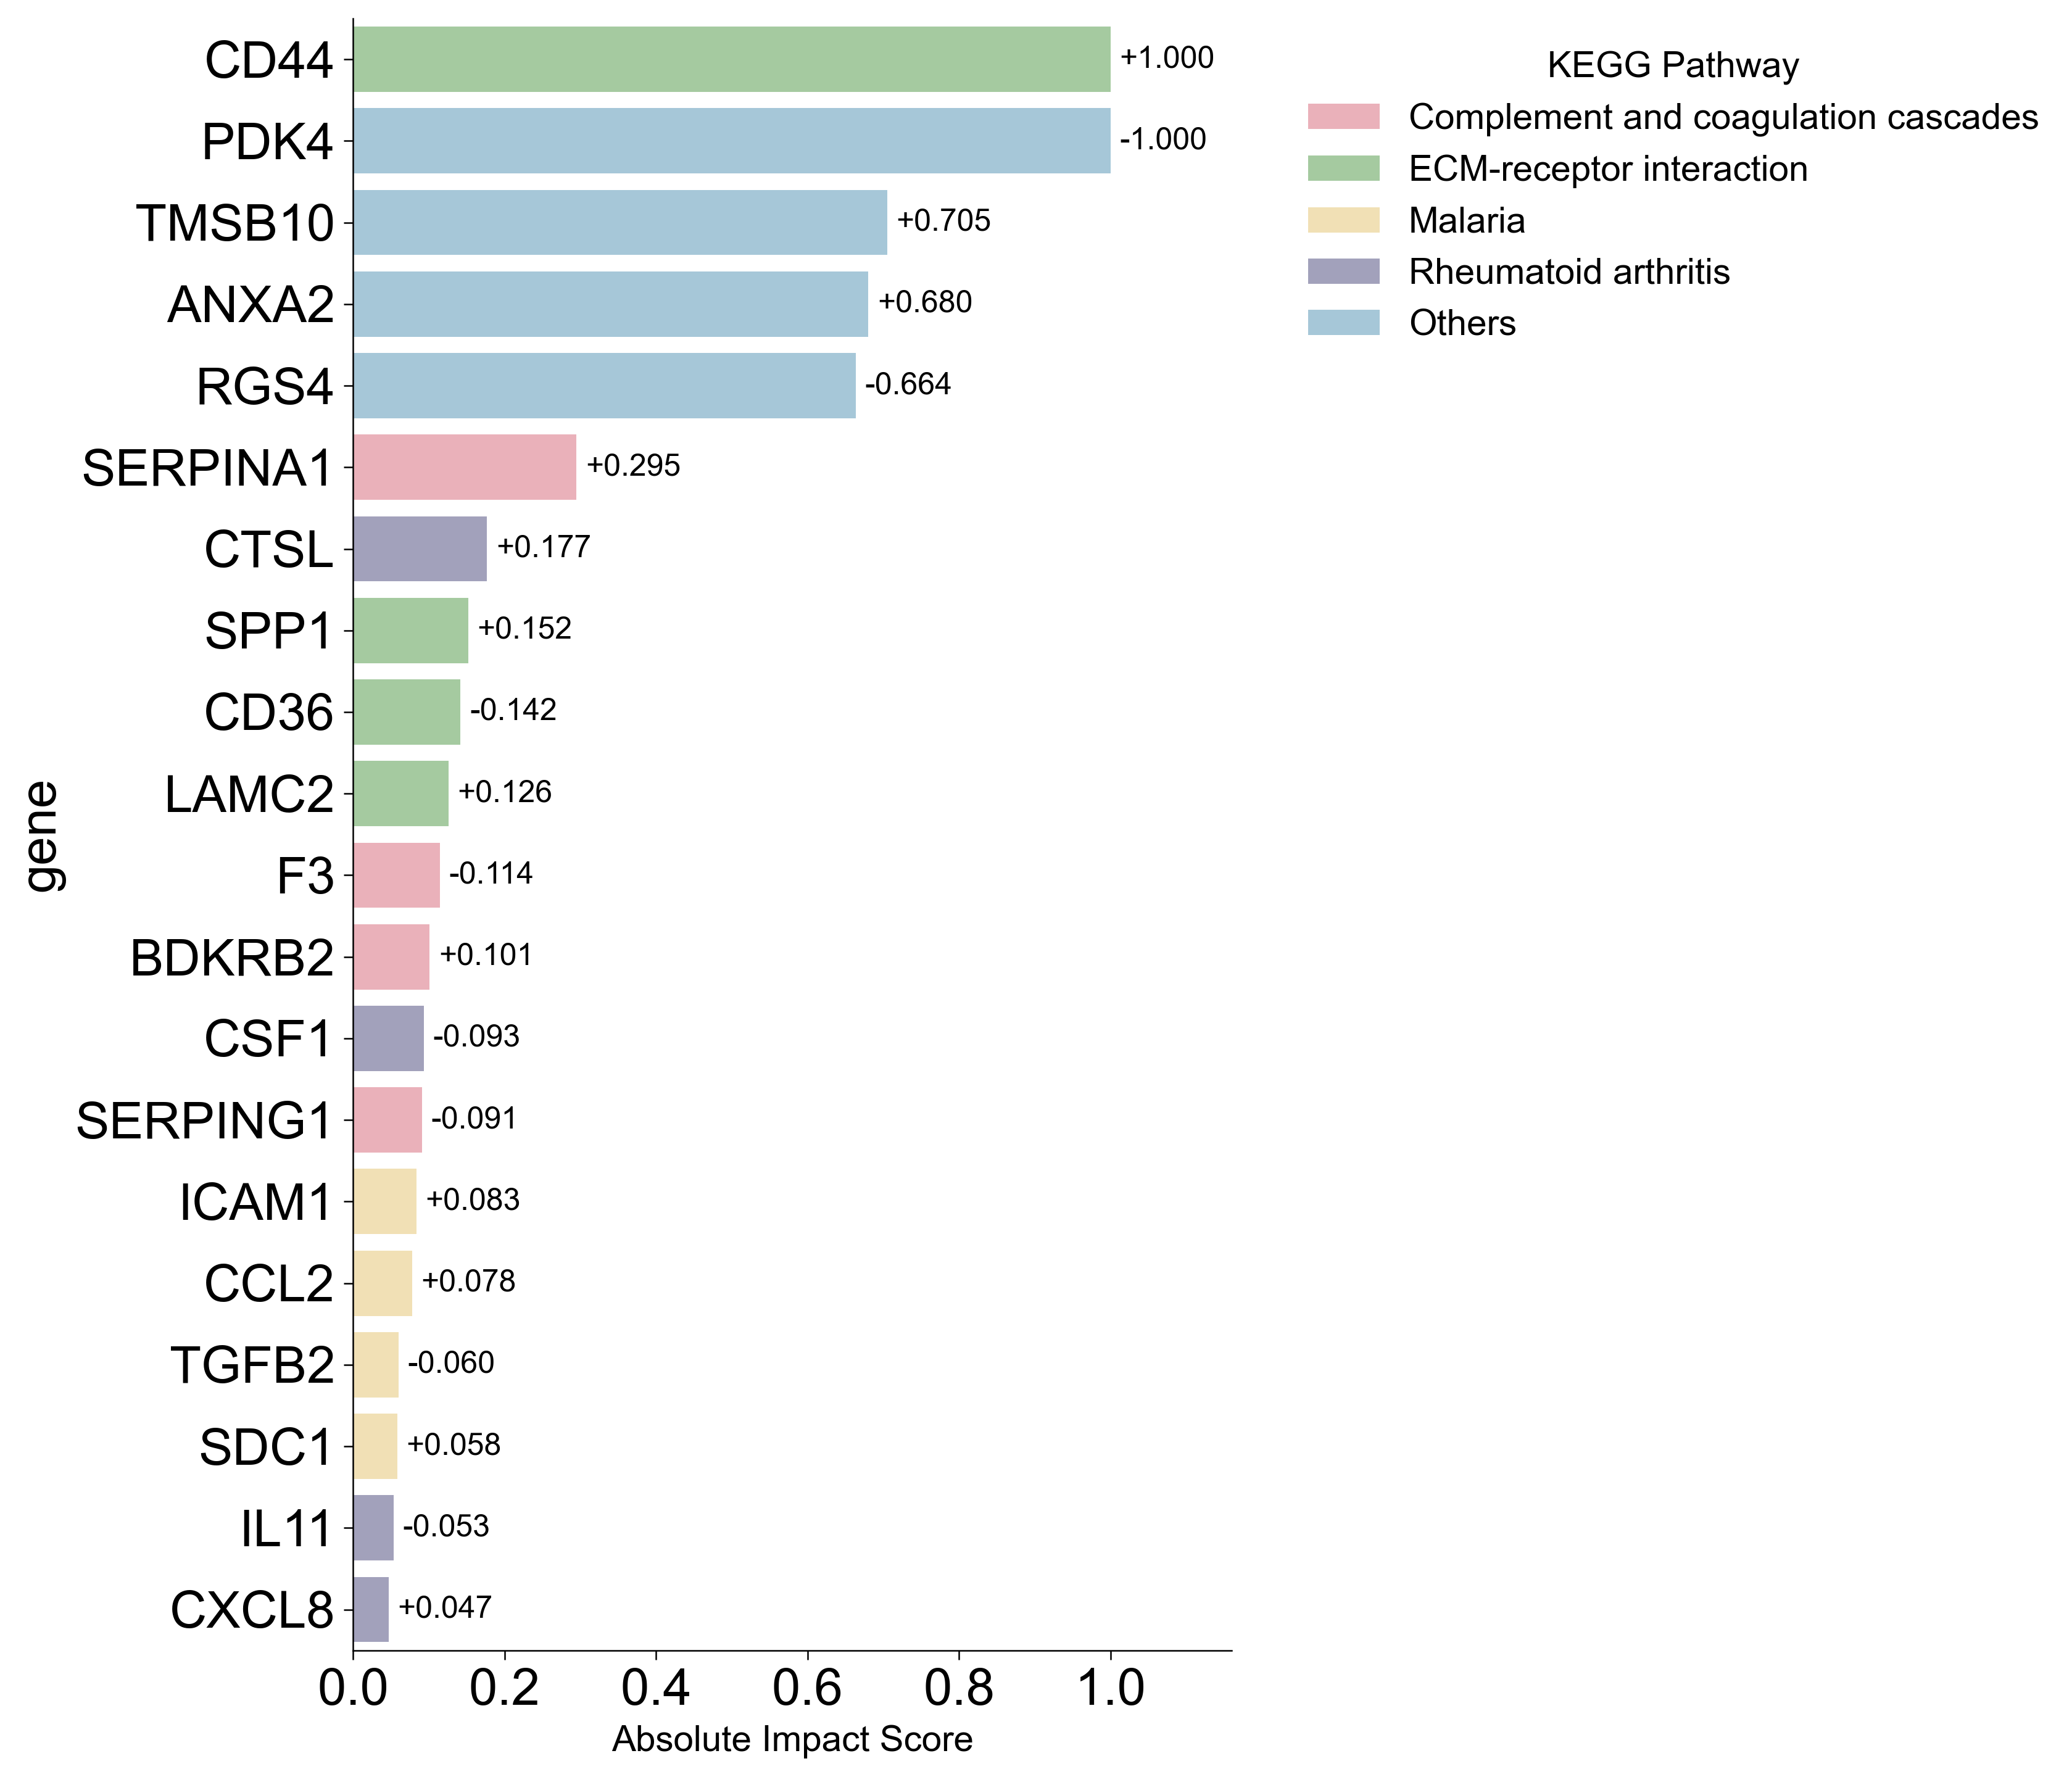

In [9]:
def plot_figure_5d(df):
    use_nature_style()

    df_plot = df.sort_values("display_order", kind="stable").copy()
    pathway_metadata = (
        df_plot.loc[df_plot["assigned_pathway"] != "Others", ["assigned_pathway", "pathway_rank"]]
        .drop_duplicates()
        .sort_values("pathway_rank", kind="stable")
    )
    pathway_order = pathway_metadata["assigned_pathway"].tolist() + ["Others"]
    pathway_colors = dict(zip(
        pathway_order,
        ["#EAB1BA", "#A5CAA0", "#F1E0B5", "#A2A1BB", "#A6C7D8"],
    ))

    with mpl.rc_context({
        "font.size": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
    }):
        fig, ax = plt.subplots(figsize=(14, 10))
        sns.barplot(
            data=df_plot,
            x="absolute_piecewise_scaled_score",
            y="gene",
            order=df_plot["gene"].tolist(),
            hue="assigned_pathway",
            hue_order=pathway_order,
            palette=pathway_colors,
            saturation=1,
            dodge=False,
            ax=ax,
        )
        ax.set_xlabel("Absolute Impact Score", fontsize=14)
        sns.despine(ax=ax)

        y_positions = ax.get_yticks()
        if len(y_positions) != len(df_plot):
            raise RuntimeError("Could not align Figure 5D signed labels with bars")
        for y_position, magnitude, signed_score in zip(
            y_positions,
            df_plot["absolute_piecewise_scaled_score"],
            df_plot["piecewise_scaled_score"],
        ):
            ax.text(
                float(magnitude) + 0.012,
                float(y_position),
                f"{float(signed_score):+.3f}",
                va="center",
                ha="left",
                fontsize=12,
            )
        ax.set_xlim(
            0.0,
            max(1.16, float(df_plot["absolute_piecewise_scaled_score"].max()) + 0.16),
        )

        handles, labels = ax.get_legend_handles_labels()
        handle_by_label = dict(zip(labels, handles))
        ax.legend(
            handles=[handle_by_label[pathway] for pathway in pathway_order],
            labels=pathway_order,
            title="KEGG Pathway",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            frameon=False,
            title_fontsize=14,
            fontsize=14,
        )
        fig.tight_layout(rect=[0, 0, 0.85, 1])
    return fig, ax


fig, ax = plot_figure_5d(figure_5d)
plt.show()

In [10]:
# Figure 5E: recompute the central 98% subset from all 1,200 gene scores.
FIGURE_5E_CSV = globals().get(
    "FIGURE_5E_CSV",
    CSV_DIR / "figure_5E.csv",
)
FIGURE_5E_TAIL_QUANTILE = 0.01


def prepare_figure_5e(score_csv, tail_quantile=0.01):
    score_csv = Path(score_csv).expanduser()
    if not score_csv.is_file():
        raise FileNotFoundError(f"Figure 5E score CSV not found: {score_csv}")
    if not 0.0 <= tail_quantile < 0.5:
        raise ValueError("Figure 5E tail quantile must lie in [0, 0.5)")

    frame = pd.read_csv(score_csv)
    required_columns = {"gene", "score"}
    missing = sorted(required_columns - set(frame.columns))
    if missing:
        raise ValueError(f"Figure 5E score CSV is missing columns: {missing}")
    if len(frame) != 1200:
        raise ValueError(f"Figure 5E requires 1,200 genes, found {len(frame)}")
    if frame["gene"].isna().any() or frame["gene"].duplicated().any():
        raise ValueError("Figure 5E genes must be unique and non-null")

    frame = frame.copy()
    frame["score"] = pd.to_numeric(frame["score"], errors="raise")
    values = frame["score"].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("Figure 5E scores must be finite")
    if np.any(np.abs(values) > 1.0 + 1e-12):
        raise ValueError("Piecewise-scaled Figure 5E scores must lie in [-1, 1]")

    lower_threshold, upper_threshold = (
        float(value)
        for value in np.quantile(
            values,
            [tail_quantile, 1.0 - tail_quantile],
            method="linear",
        )
    )
    lower_tail = values < lower_threshold
    upper_tail = values > upper_threshold
    retained = ~(lower_tail | upper_tail)
    frame["central_98_status"] = np.select(
        [lower_tail, upper_tail],
        ["excluded_lower_tail", "excluded_upper_tail"],
        default="retained",
    )
    frame["included_in_central_98"] = retained

    trim_summary = {
        "tail_quantile_each_side": float(tail_quantile),
        "lower_threshold": lower_threshold,
        "upper_threshold": upper_threshold,
        "input_count": int(values.size),
        "retained_count": int(np.count_nonzero(retained)),
        "excluded_lower_count": int(np.count_nonzero(lower_tail)),
        "excluded_upper_count": int(np.count_nonzero(upper_tail)),
    }
    if (
        trim_summary["retained_count"] != 1176
        or trim_summary["excluded_lower_count"] != 12
        or trim_summary["excluded_upper_count"] != 12
    ):
        raise ValueError("Figure 5E central 98% trimming did not retain 1,176 genes")

    plot_frame = frame.loc[retained].copy().reset_index(drop=True)
    return frame, plot_frame, trim_summary


figure_5e_all, figure_5e_plot, figure_5e_trim = prepare_figure_5e(
    FIGURE_5E_CSV,
    tail_quantile=FIGURE_5E_TAIL_QUANTILE,
)

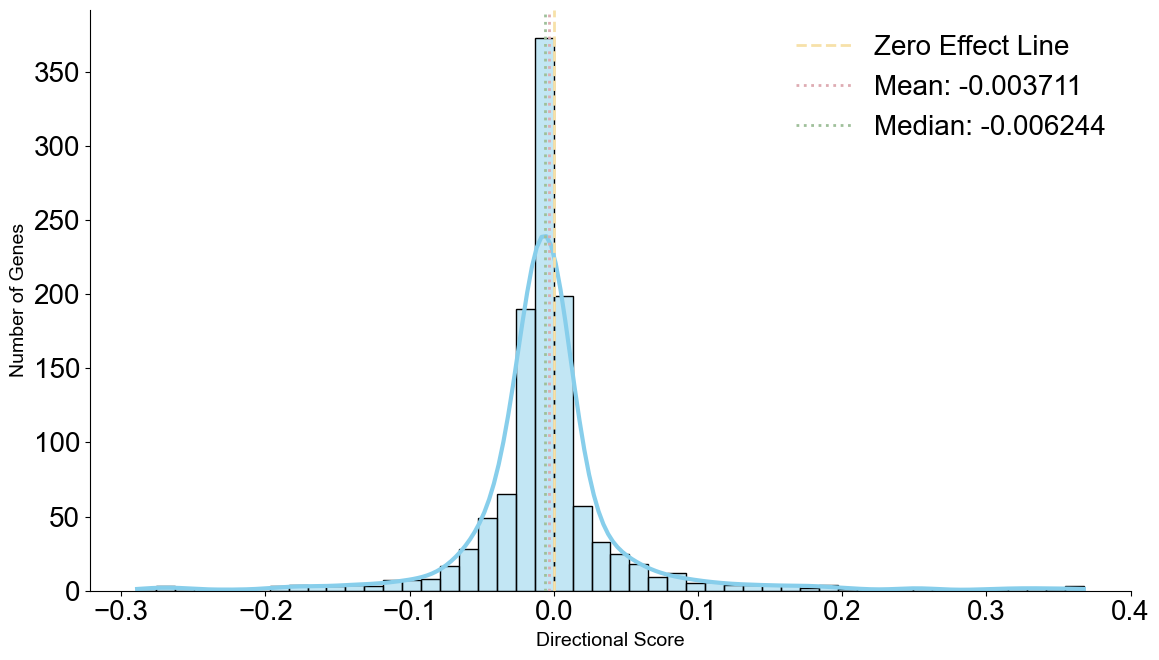

In [11]:
def plot_figure_5e(df):
    use_nature_style()
    figure_5e_font_family = mpl.rcParams["font.family"]
    score_column = "score"
    mean_value = float(df[score_column].mean())
    median_value = float(df[score_column].median())

    with mpl.rc_context(rc=mpl.rcParamsDefault):
        mpl.rcParams["svg.fonttype"] = "none"
        mpl.rcParams["font.family"] = figure_5e_font_family
        mpl.rcParams["font.size"] = 20
        fig, ax = plt.subplots(figsize=(12, 7))
        sns.histplot(
            data=df,
            x=score_column,
            kde=True,
            bins=50,
            color="skyblue",
            line_kws={"linewidth": 3, "color": "steelblue"},
            ax=ax,
        )
        ax.axvline(
            x=0.0,
            color="#F7E1A9",
            linestyle="--",
            linewidth=2,
            label="Zero Effect Line",
        )
        ax.axvline(
            x=mean_value,
            color="#DEABB2",
            linestyle=":",
            linewidth=2,
            label=f"Mean: {mean_value:.6f}",
        )
        ax.axvline(
            x=median_value,
            color="#9FC09A",
            linestyle=":",
            linewidth=2,
            label=f"Median: {median_value:.6f}",
        )
        ax.set_xlabel("Directional Score", fontsize=14)
        ax.set_ylabel("Number of Genes", fontsize=14)
        ax.legend(frameon=False)
        sns.despine(ax=ax)
        fig.tight_layout()
    return fig, ax


fig, ax = plot_figure_5e(figure_5e_plot)
plt.show()

# Figure 5F — Ablation of scRNA-seq embedding fusion strategies

Figure 5F compares three ways of integrating scRNA-seq embeddings into Melody-G: **FiLM**, **Cell linear**, and **Generate**. In the manuscript, feature-wise linear modulation (FiLM) shows the best overall performance in this benchmark, indicating that directly modulating sequence features with cell-state information is more effective than simpler linear embedding or parameter-generation strategies.

Each row in the CSV is one fusion strategy, and each column is one unseen cell type. The plot uses the same mean bar, standard-deviation error bar, and scatter style as Figure 5A.

In [12]:
figure_5f = load_auc_panel(
    "Figure 5F",
    "figure_5F.csv",
    row_order=["FiLM", "Cell linear", "Generate"],
)

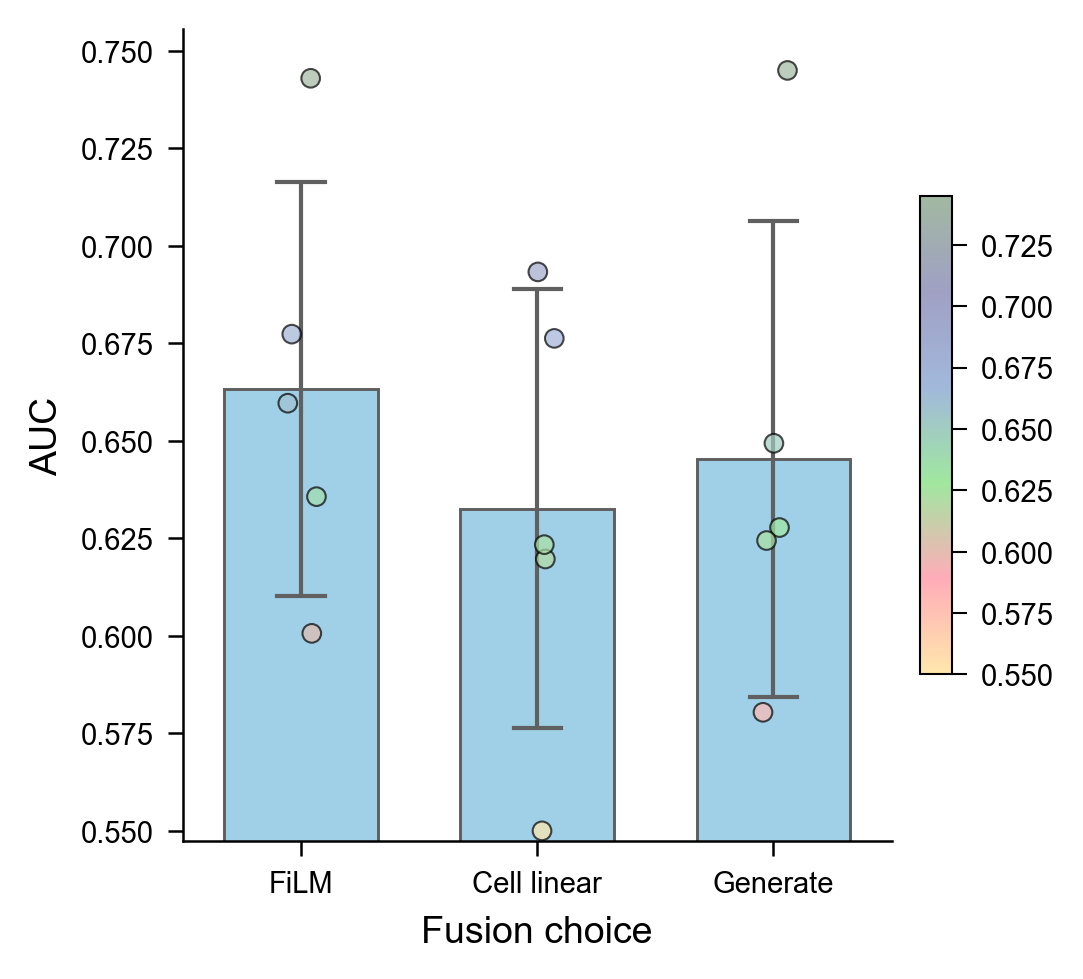

In [13]:
fig, ax = plot_auc_panel(figure_5f, xlabel="Fusion choice")
plt.show()

# Figure 5G — Effect of scRNA-seq sample size

Figure 5G tests whether Melody-G benefits from comprehensive cellular data by comparing embeddings computed from all available cells with embeddings from smaller sampled subsets. The manuscript reports that reducing the number of cells markedly decreases performance, supporting the idea that richer transcriptomic sampling provides more reliable cell-state guidance.

Rows represent scRNA-seq sampling settings, and columns represent the same five unseen cell types used in Figure 5A.

In [14]:
figure_5g = load_auc_panel(
    "Figure 5G",
    "figure_5G.csv",
    row_order=["all", "sample 1", "sample 10%"],
)

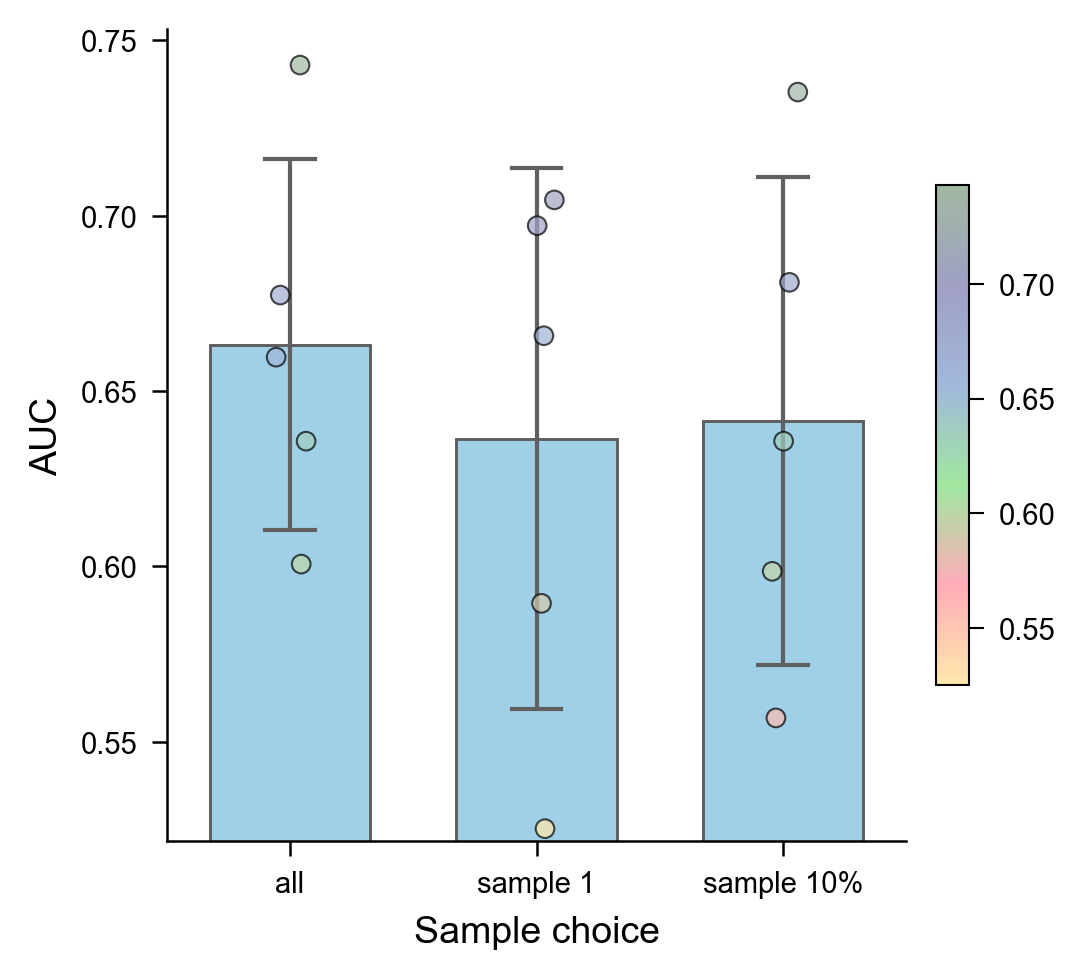

In [15]:
fig, ax = plot_auc_panel(figure_5g, xlabel="Sample choice")
plt.show()

# Figure 5H — Effect of scRNA-seq foundation model choice

Figure 5H compares embeddings generated by three single-cell foundation models: **scGPT**, **scFoundation**, and **CellFM**. In the original benchmark, scGPT shows the strongest overall performance, while the manuscript notes that the relative ranking can vary under more stringent unseen splits.

Rows represent the upstream foundation model used to generate cell-state embeddings; columns are the five unseen cell types.

In [16]:
figure_5h = load_auc_panel(
    "Figure 5H",
    "figure_5H.csv",
    row_order=["scGPT", "scFoundation", "CellFM"],
)

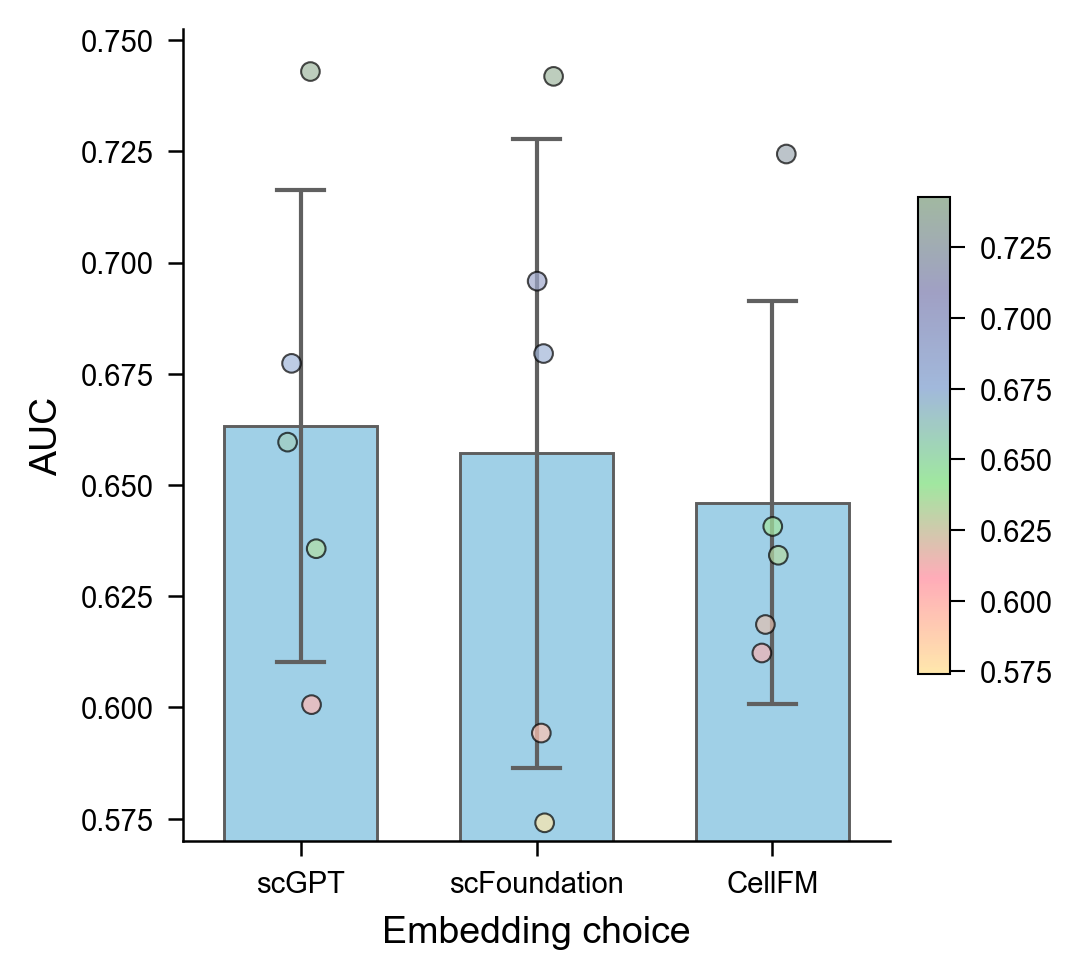

In [17]:
fig, ax = plot_auc_panel(figure_5h, xlabel="Embedding choice")
plt.show()